# IS 470 Assignment 4: (Three tasks)

##Assignment 4 covers three unrelated tasks:

* Part A: Clustering using K-means
* Part B: Association Rule Minining using Apriori
* Part C: Ensemble Models

<b>Objective Part A:</b>

In this task we are given a dataset with information about the Iris Flowers including petal length, width and other measurements. The goal is to classify them into distinct clusters.

In [56]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [57]:
# Install apyori
# note: this is fundamentally different than all the other imports so i put it here
! pip install apyori

In [163]:
# Import libraries
import pandas as pd               # used for data analysis and manipulation
import seaborn as sns             # used for data visualization (used for lots of charts, box plot, scatter plot etc...)
import matplotlib.pyplot as plt   # used for data visualization (specifically for plotting the decision tree classifier)

from collections import Counter   # used for counting stuff i guess?
import sklearn as sk              # used for a bunch of things, DecisionTreeClassifier and more.
import numpy as np                # used for numbers and such

from csv import reader            # I guess this reader thing reads csv files like text and then converst to objects per row
from apyori import apriori        # This is needed for association rule mining



In [59]:
iris = pd.read_csv('/content/drive/MyDrive/IS470_data/Iris.csv')
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,7.9,3.8,6.4,2.0
1,7.7,3.8,6.7,2.2
2,7.7,3.0,6.1,2.3
3,7.7,2.8,6.7,2.0
4,7.7,2.6,6.9,2.3


##Data Understanding
Let see... there's not really a lot of data here, just the fields which are all numeric measurements in centimeters of petal and sepals (a petal and a sepal kinda look similar but the sepal is bigger and sorta has a stem section... google it)

In [60]:
# data types
iris.dtypes

,0
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64


In [61]:
# minmax normalization
min_max_scaler = sk.preprocessing.MinMaxScaler()
iris_normalized = pd.DataFrame(min_max_scaler.fit_transform(iris))
iris_normalized.columns = iris.columns
iris_normalized.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1.000000,0.750000,0.915254,0.791667
1,0.944444,0.750000,0.966102,0.875000
2,0.944444,0.416667,0.864407,0.916667
3,0.944444,0.333333,0.966102,0.791667
4,0.944444,0.250000,1.000000,0.916667


In [62]:
# build 2 cluster model
model_2 = sk.cluster.KMeans(n_clusters=2, random_state=42)
model_2.fit(iris_normalized)

KMeans(n_clusters=2, random_state=42)

In [63]:
# show the cluster labels
Counter(model_2.labels_)

Counter({np.int32(0): 100, np.int32(1): 50})

In [64]:
# show cluster centroids
pd.DataFrame({'cluster 1':iris[model_2.labels_==0].mean(axis=0), 'cluster 2':iris[model_2.labels_==1].mean(axis=0)})

,cluster 1,cluster 2
SepalLengthCm,6.262,5.006
SepalWidthCm,2.872,3.418
PetalLengthCm,4.906,1.464
PetalWidthCm,1.676,0.244


In [65]:
# build 3 cluster model
model_3 = sk.cluster.KMeans(n_clusters=3, random_state=42)
model_3.fit(iris_normalized)

KMeans(n_clusters=3, random_state=42)

In [66]:
# show the cluster labels
Counter(model_3.labels_)

Counter({np.int32(2): 39, np.int32(0): 61, np.int32(1): 50})

In [67]:
# show cluster centroids
pd.DataFrame({
    'cluster 1':iris[model_3.labels_==0].mean(axis=0),
    'cluster 2':iris[model_3.labels_==1].mean(axis=0),
    'cluster 3':iris[model_3.labels_==2].mean(axis=0)
})

,cluster 1,cluster 2,cluster 3
SepalLengthCm,5.888525,5.006,6.846154
SepalWidthCm,2.737705,3.418,3.082051
PetalLengthCm,4.396721,1.464,5.702564
PetalWidthCm,1.418033,0.244,2.079487


Text(0.5, 1.0, 'Elbow test')

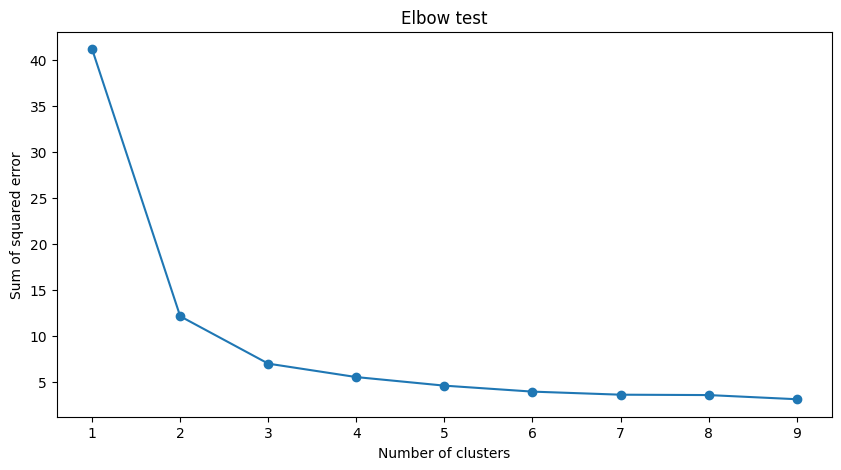

In [68]:
# Elbow test
sum_of_squared_error = []
for k in range(1, 10):
  kmeans = sk.cluster.KMeans(n_clusters=k, random_state=42)
  kmeans.fit(iris_normalized)
  sum_of_squared_error.append(kmeans.inertia_)

fig = plt.figure(figsize=(10, 5))
plt.scatter(range(1, 10), sum_of_squared_error)
plt.plot(range(1, 10), sum_of_squared_error)
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared error')
plt.title('Elbow test')

Initial analysis would suggest the ideal number of clusters is two.  I say this because the angle is the furthest from 180-degrees (and closest to 90 degrees) at this point.<br/><br/>

However, after reading through the wiki page on this subject: https://en.wikipedia.org/wiki/Iris_flower_data_set  (much of which was beyond my understanding because it was not covered in this class). I think i have a general understanding of what is going on here.<br/><br/>
In the two cluster set you have a grouping of 50 and another of 100.  I know from the wiki article that there are 50 of each species and I can tell from the images there that the set with 50 is the one that contains iris setosa.  The other set contains both iris versicolor and iris virginica.  I also understand that we cannot use k-means clustering to divide the larger set any better with this set of data.  For this reason, I would name the clusters as such:<br/><br/>
* Set 1: Iris Setosa (size 50)
* Set 2: Iris Versicolor & Verginica (size 100)<br/>
<br/>
Note: The three-cluster set simply does not divide the species clearly so it should not be used.
<br/>
<br/>
Final Note: Without the data which says which species is associated with each record, there would be no way to know that the three-cluster grouping is in fact messed up.  I suppose my initial assumption that the highest-angled-point in the elbow test is the best one to choose is in fact correct in this particular instance. That said, I am not convinced that the Elbow test is a difinitive way of making this conclusion.
<br/>

**Objective Part B:**<br/>
In this task we are given information about items purchased by customers from an online retailer. The goal is to determine assoication rules and to impart thier significance with respect to the business

In [69]:
# import the data
# note, because each row has a varying number of values we can not import it like a spreasheet
transactions = []
with open('/content/drive/MyDrive/IS470_data/OnlineRetailTransactions.csv', 'r') as read_obj:
  csv_reader = reader(read_obj)
  for row in csv_reader:
    transactions.append(row) #note, row is an array of all the objects

In [70]:
# Inspect the first 5 transactions (notice how it auto-magically puts double quotes around the fields which have quotes in them...neat!)
transactions[:5]

[['white hanging heart t-light holder',
  ' white metal lantern',
  ' cream cupid hearts coat hanger',
  ' knitted union flag hot water bottle',
  ' red woolly hottie white heart.',
  ' set 7 babushka nesting boxes',
  ' glass star frosted t-light holder'],
 ['hand warmer union jack', ' hand warmer red polka dot'],
 ['assorted colour bird ornament',
  " poppy's playhouse bedroom ",
  " poppy's playhouse kitchen",
  ' feltcraft princess charlotte doll',
  ' ivory knitted mug cosy ',
  ' box of 6 assorted colour teaspoons',
  ' box of vintage jigsaw blocks ',
  ' box of vintage alphabet blocks',
  ' home building block word',
  ' love building block word',
  ' recipe box with metal heart',
  ' doormat new england'],
 ['jam making set with jars',
  ' red coat rack paris fashion',
  ' yellow coat rack paris fashion',
  ' blue coat rack paris fashion'],
 ['bath building block word']]

In [71]:
# Implement apriori algorithm
transactions_rules = apriori(transactions, min_support=0.014, min_confidence=0.3, min_lift=3, max_length=2)
transactions_rules = list(transactions_rules)

In [72]:
# Display rules
rules = pd.DataFrame(columns=('LHS', 'RHS', 'Support', 'Confidence', 'Lift'))
for i in range(len(transactions_rules)):
  for rule_ in transactions_rules[i].ordered_statistics:
    rules = pd.concat([rules,
      pd.DataFrame({
          'LHS': [','.join(list(rule_.items_base))],
          'RHS': [','.join(list(rule_.items_add))],
          'Support': [transactions_rules[i].support],
          'Confidence': [rule_.confidence],
          'Lift': [rule_.lift]
      })
    ], ignore_index=True)

# pd.options.display.max_rows = 200
rules_sorted = rules.sort_values(by="Lift", ascending=False)
rules_sorted

/tmp/ipython-input-1785597292.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rules = pd.concat([rules,


,LHS,RHS,Support,Confidence,Lift
157,set 3 retrospot tea,sugar,0.016332,1.000000,58.863636
158,sugar,set 3 retrospot tea,0.016332,0.961364,58.863636
86,shed,key fob,0.014324,0.989333,49.087612
85,key fob,shed,0.014324,0.710728,49.087612
155,set 3 retrospot tea,coffee,0.016332,1.000000,48.230912
...,...,...,...,...,...
78,red retrospot charlotte bag,jumbo bag red retrospot,0.015985,0.406281,5.175932
76,lunch bag red retrospot,jumbo bag red retrospot,0.021467,0.364351,4.641760
162,wooden picture frame white finish,white hanging heart t-light holder,0.014324,0.344796,4.258562
140,natural slate heart chalkboard,white hanging heart t-light holder,0.015328,0.329187,4.065786


### Top 5 Rules and their significance



1.   set 3 retrospot tea -> sugar  - This insight is not particularly interesting, so, if you buy a set of three teacups you also buy sugar.

2.   sugar -> set 3 retrospot tea  - Even less interesting, just the inverse

3.   shed -> keyfob  - ok, slightly less obvious but yea if you buy a shed i guess there is a high likelihood that you'd also buy a keyfob so perhaps sell one near the other

4.   keyfob -> shed  - again the inverse, i wish there was a way to remove these (I'm sure there is)

5.   set 3 retrospot tea -> coffee  - again with the tea set...



### Additional thoughts

This was not asked for in the assignment, but to me simply looking at lift is not a very good way to gain valuable business insights.  What would be much more interesting is if you also correlated other values along with lift.  For example, if you could get category information about the products as well, or even store placement locations and then find products which have lift associated with them but are in different categories and/or different locations in the store that would be much more interesting.<br/><br/>Like the Baby Diaper/Beer example from the lecture, this is way more interesting and it seems to me more actionable that just going 'oh shucks i guess people buy coffee and sugar together'.  Like, yea that may be true, but who cares?

**Objective Part C:**

We have been given a dataset about people who were on the Titanic.  The goal is to figure out what kind of people survived, and which ones did not.

In [111]:
# Read data
Titanic = pd.read_csv("/content/drive/MyDrive/IS470_data/Titanic.csv")
Titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [112]:
# Examine variable type
Titanic.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [113]:
# lets look closer at some of the values
print('Name', Titanic['Name'].nunique())
print('Sex', Titanic['Sex'].nunique())
print('Ticket', Titanic['Ticket'].nunique())
print('Cabin', Titanic['Cabin'].nunique())
print('Embarked', Titanic['Embarked'].nunique())

Name 891
Sex 2
Ticket 681
Cabin 147
Embarked 3


Based on the analysis above, I am going to suggest we remove Name, Ticket and Cabin because they are too divergent to make any realistic predictions with them. if we were to dummy code them we would have way to many columns. The other values should remain

In [114]:
# Drop unneccessary columns
# Titanic = Titanic.drop(columns=['Name'])  //Note, we can't drop this yet, becuase we need it later
Titanic = Titanic.drop(columns=['Ticket'])
Titanic = Titanic.drop(columns=['Cabin'])


In [115]:
# Change remaining categorical variables to category
Titanic['Sex'] = Titanic['Sex'].astype('category')
Titanic['Embarked'] = Titanic['Embarked'].astype('category')

In [116]:
# Create dummy variables
Titanic = pd.get_dummies(Titanic, columns=['Sex', 'Embarked'], drop_first=True)

In [117]:
# Look at the variable types again
Titanic.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Sex_male,bool
Embarked_Q,bool


In [118]:
# Identify NULL values per column
Titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Age,177
SibSp,0
Parch,0
Fare,0
Sex_male,0
Embarked_Q,0


Based on the above analysis, it seems that Age is the only value which has nulls.  I talked to the robot (ChatGPT) and it suggested a way of estimating this which seems fairly logical to me.  The idea here is to first extract the Title from the Name field (it does this using a regex) and then based on the title you would guess the ages.  So, for example a title of "Mr" might be set at 40 years old, "Mrs" might be at 35, "Ms" might be 25 etc...<br/><br/>For this purpose, I will need to keep the name value which I had previously dropped, so I am going to go back and comment out that line of code, then perform this analysis, estimate the ages, then drop it.

In [119]:
# Extract titles
Titanic['Title'] = Titanic['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)
Titanic['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [120]:
# fill in missing ages by average for title
Titanic['Age'] = Titanic.groupby('Title')['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [121]:
# Check null values again
Titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_male,0
Embarked_Q,0


In [122]:
# remove name and title
Titanic = Titanic.drop(columns=['Name'])
Titanic = Titanic.drop(columns=['Title'])

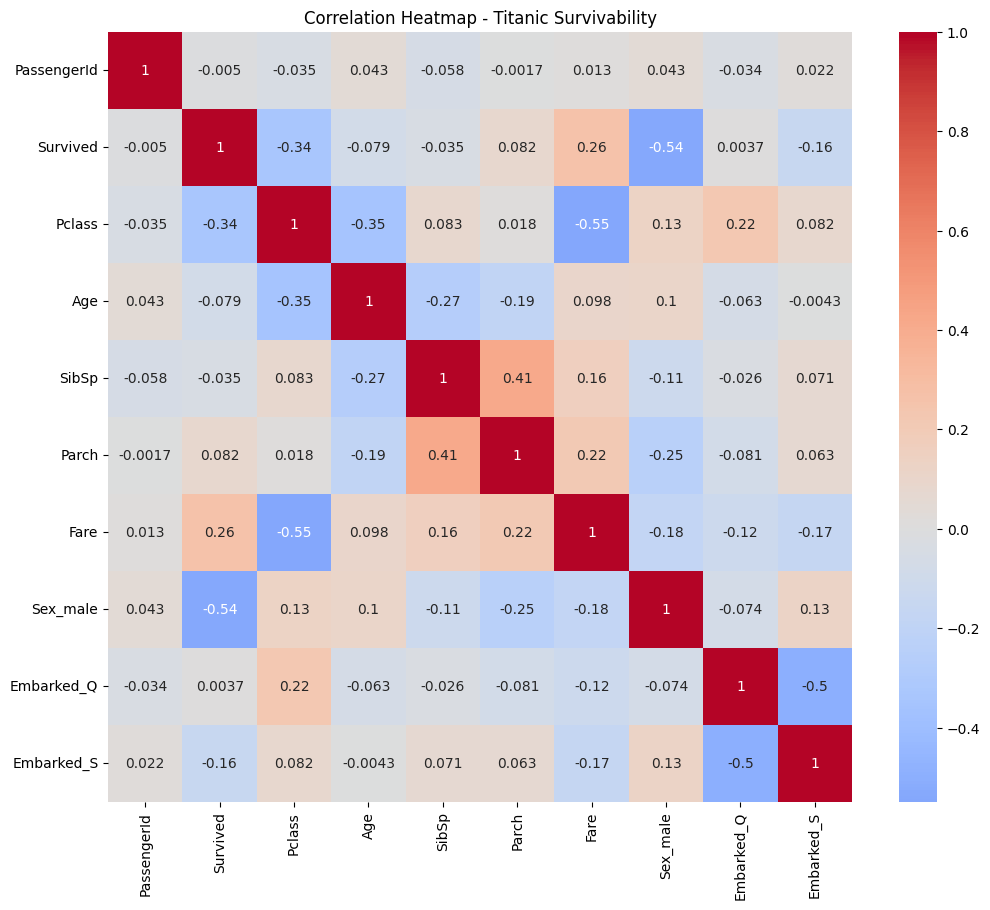

In [123]:
# lets use a heatmap to visualize correlation
plt.figure(figsize=(12, 10))
sns.heatmap(Titanic.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Titanic Survivability')
plt.show()

Before we start creating models. we need a way to save all of this data so that we can generate a report at the end of it all.  We will do this by creating a reports object that we will add all the repor values too

In [124]:
reports = {}

## Voting Ensemble

In [125]:
# Partition the data
target = Titanic['Survived']
predictors = Titanic.drop(columns=['Survived'])
p_train, p_test, t_train, t_test = sk.model_selection.train_test_split(predictors, target, test_size=0.3, random_state=42)
print(p_train.shape, p_test.shape, t_train.shape, t_test.shape)

(623, 9) (268, 9) (623,) (268,)


In [126]:
# Create five learners
estimators = []
learner_1 = sk.tree.DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
estimators.append(('DT', learner_1))
learner_2 = sk.svm.SVC(C=3)
estimators.append(('SVM', learner_2))
learner_3 = sk.neural_network.MLPClassifier(hidden_layer_sizes=(16,8), max_iter=1000, random_state=42)
estimators.append(('MLP', learner_3))
learner_4 = sk.ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
estimators.append(('RF', learner_4))
learner_5 = sk.neighbors.KNeighborsClassifier(n_neighbors=3)
estimators.append(('KNN', learner_5))

In [127]:
# Create a voting model
model_voting = sk.ensemble.VotingClassifier(estimators)
model_voting.fit(p_train, t_train)

VotingClassifier(estimators=[('DT',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=3,
                                                     random_state=42)),
                             ('SVM', SVC(C=3)),
                             ('MLP',
                              MLPClassifier(hidden_layer_sizes=(16, 8),
                                            max_iter=1000, random_state=42)),
                             ('RF', RandomForestClassifier(random_state=42)),
                             ('KNN', KNeighborsClassifier(n_neighbors=3))])

In [128]:
# make predictions on testing data
predictions_on_test = model_voting.predict(p_test)

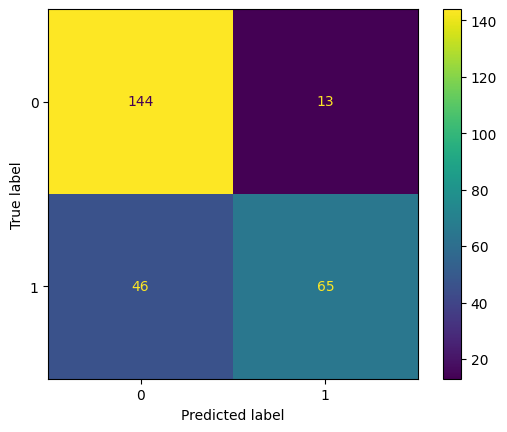

In [129]:
# examine confusion matrix of testing data
cm = sk.metrics.confusion_matrix(t_test, predictions_on_test)
sk.metrics.ConfusionMatrixDisplay(cm).plot()

In [130]:
# check out the classification report for Voting Ensemble (output dictionary for final report)
reports['Voting Ensemble'] = sk.metrics.classification_report(t_test, predictions_on_test, output_dict=True)
# do it again without the dumb output dictionary thing so we can actually fucking see it
print(sk.metrics.classification_report(t_test, predictions_on_test))

              precision    recall  f1-score   support

           0       0.76      0.92      0.83       157
           1       0.83      0.59      0.69       111

    accuracy                           0.78       268
   macro avg       0.80      0.75      0.76       268
weighted avg       0.79      0.78      0.77       268



## Bagging Classifier

In [131]:
# create a bagging clasifier
model_bagging = sk.ensemble.BaggingClassifier(
    estimator=sk.tree.DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        max_depth=3
    ),
    n_estimators=20,
    random_state=42
)
model_bagging.fit(p_train, t_train)

BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                   max_depth=3,
                                                   random_state=42),
                  n_estimators=20, random_state=42)

In [132]:
# make predictions on testing data
predictions_on_test = model_bagging.predict(p_test)

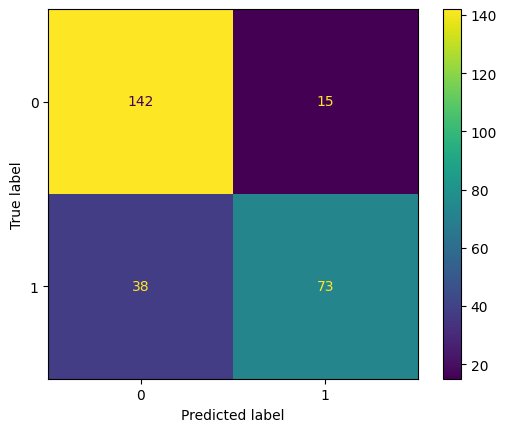

In [133]:
# confusion matrix
cm = sk.metrics.confusion_matrix(t_test, predictions_on_test)
sk.metrics.ConfusionMatrixDisplay(cm).plot()

In [134]:
# check out the classification report for Bagging Classifier
reports['Bagging Classifier'] = sk.metrics.classification_report(t_test, predictions_on_test, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       157
           1       0.83      0.66      0.73       111

    accuracy                           0.80       268
   macro avg       0.81      0.78      0.79       268
weighted avg       0.81      0.80      0.80       268



## Boosting Classifier

In [135]:
# create boosting classifier
model_boosting = sk.ensemble.AdaBoostClassifier(
    estimator=sk.tree.DecisionTreeClassifier(
        criterion="entropy",
        random_state=4,
        max_depth=3
    ),
    n_estimators=20,
    random_state=4
)
model_boosting.fit(p_train, t_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=3,
                                                    random_state=4),
                   n_estimators=20, random_state=4)

In [136]:
# make predicitons
predictions_on_test = model_boosting.predict(p_test)

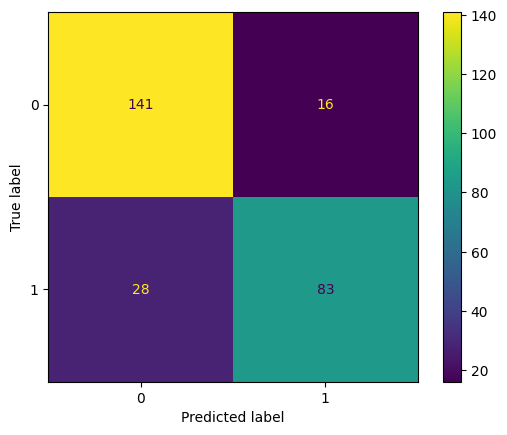

In [137]:
# examine matrix
cm = sk.metrics.confusion_matrix(t_test, predictions_on_test)
sk.metrics.ConfusionMatrixDisplay(cm).plot()

In [138]:
# check out the classification report for Boosting Classifier
reports['Boosting Classifier'] = sk.metrics.classification_report(t_test, predictions_on_test, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87       157
           1       0.84      0.75      0.79       111

    accuracy                           0.84       268
   macro avg       0.84      0.82      0.83       268
weighted avg       0.84      0.84      0.83       268



## Model Enhancement
In this section we will try to make our existing models better

Voting Ensemble Enhancement

In [141]:
# Create five learners (with different metrics)
estimators = []
learner_1 = sk.tree.DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
estimators.append(('DT', learner_1))
learner_2 = sk.svm.SVC(C=4)
estimators.append(('SVM', learner_2))
learner_3 = sk.neural_network.MLPClassifier(hidden_layer_sizes=(32,16,8), max_iter=5000, random_state=42)
estimators.append(('MLP', learner_3))
learner_4 = sk.ensemble.RandomForestClassifier(n_estimators=200, random_state=42)
estimators.append(('RF', learner_4))
learner_5 = sk.neighbors.KNeighborsClassifier(n_neighbors=5)
estimators.append(('KNN', learner_5))

In [142]:
# Create a voting model
model_voting_2 = sk.ensemble.VotingClassifier(estimators)
model_voting_2.fit(p_train, t_train)

VotingClassifier(estimators=[('DT',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=4,
                                                     random_state=42)),
                             ('SVM', SVC(C=4)),
                             ('MLP',
                              MLPClassifier(hidden_layer_sizes=(32, 16, 8),
                                            max_iter=5000, random_state=42)),
                             ('RF',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=42)),
                             ('KNN', KNeighborsClassifier())])

In [143]:
# make predictions on testing data
predictions_on_test_2 = model_voting_2.predict(p_test)

In [144]:
# check out the classification report for Voting Ensemble (output dictionary for final report)
reports['Voting Ensemble 2'] = sk.metrics.classification_report(t_test, predictions_on_test_2, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test_2))

              precision    recall  f1-score   support

           0       0.72      0.96      0.82       157
           1       0.90      0.47      0.62       111

    accuracy                           0.76       268
   macro avg       0.81      0.72      0.72       268
weighted avg       0.79      0.76      0.74       268



Bagging Classifier Enhancement

In [148]:
# create a bagging clasifier (enhanced)
model_bagging_2 = sk.ensemble.BaggingClassifier(
    estimator=sk.tree.DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        max_depth=4
    ),
    n_estimators=30,
    random_state=42
)
model_bagging_2.fit(p_train, t_train)

BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                   max_depth=4,
                                                   random_state=42),
                  n_estimators=30, random_state=42)

In [150]:
# make predictions on testing data
predictions_on_test_2 = model_bagging_2.predict(p_test)

In [151]:
# check out the classification report for Voting Ensemble (output dictionary for final report)
reports['Bagging Classifier 2'] = sk.metrics.classification_report(t_test, predictions_on_test_2, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test_2))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       157
           1       0.85      0.65      0.73       111

    accuracy                           0.81       268
   macro avg       0.82      0.78      0.79       268
weighted avg       0.81      0.81      0.80       268



Boosting Classifier Enhancement

In [156]:
# create boosting classifier
model_boosting_2 = sk.ensemble.AdaBoostClassifier(
    estimator=sk.tree.DecisionTreeClassifier(
        criterion="entropy",
        random_state=5,
        max_depth=4
    ),
    n_estimators=30,
    random_state=4
)
model_boosting_2.fit(p_train, t_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                    max_depth=4,
                                                    random_state=5),
                   n_estimators=30, random_state=4)

In [157]:
# make predictions on testing data
predictions_on_test_2 = model_boosting_2.predict(p_test)

In [158]:
# check out the classification report for Voting Ensemble (output dictionary for final report)
reports['Boosting Classifier 2'] = sk.metrics.classification_report(t_test, predictions_on_test_2, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test_2))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       157
           1       0.82      0.71      0.76       111

    accuracy                           0.82       268
   macro avg       0.82      0.80      0.81       268
weighted avg       0.82      0.82      0.81       268



## Single Models

Note: honestly this is getting very tedious and boring. If i wanted to write standards on the chalk board I would have joined a 3rd grade math class.  Literally everything here has already been done in previous assignments.  If this were in fact my job, at least I would be getting paid for it (not enough mind you, but better than nothing)

Decision tree analysis

In [161]:
model_dt = sk.tree.DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
model_dt.fit(p_train, t_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

[Text(0.3897058823529412, 0.9166666666666666, 'Sex_male <= 0.5\nentropy = 0.951\nsamples = 623\nvalue = [392, 231]\nclass = Dead'),
 Text(0.19117647058823528, 0.75, 'Pclass <= 2.5\nentropy = 0.845\nsamples = 213\nvalue = [58, 155]\nclass = Alive'),
 Text(0.2904411764705882, 0.8333333333333333, 'True  '),
 Text(0.11764705882352941, 0.5833333333333334, 'PassengerId <= 502.0\nentropy = 0.225\nsamples = 110\nvalue = [4, 106]\nclass = Alive'),
 Text(0.08823529411764706, 0.4166666666666667, 'PassengerId <= 498.0\nentropy = 0.353\nsamples = 60\nvalue = [4, 56]\nclass = Alive'),
 Text(0.058823529411764705, 0.25, 'Age <= 2.5\nentropy = 0.29\nsamples = 59\nvalue = [3, 56]\nclass = Alive'),
 Text(0.029411764705882353, 0.08333333333333333, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = Dead'),
 Text(0.08823529411764706, 0.08333333333333333, 'entropy = 0.216\nsamples = 58\nvalue = [2, 56]\nclass = Alive'),
 Text(0.11764705882352941, 0.25, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = D

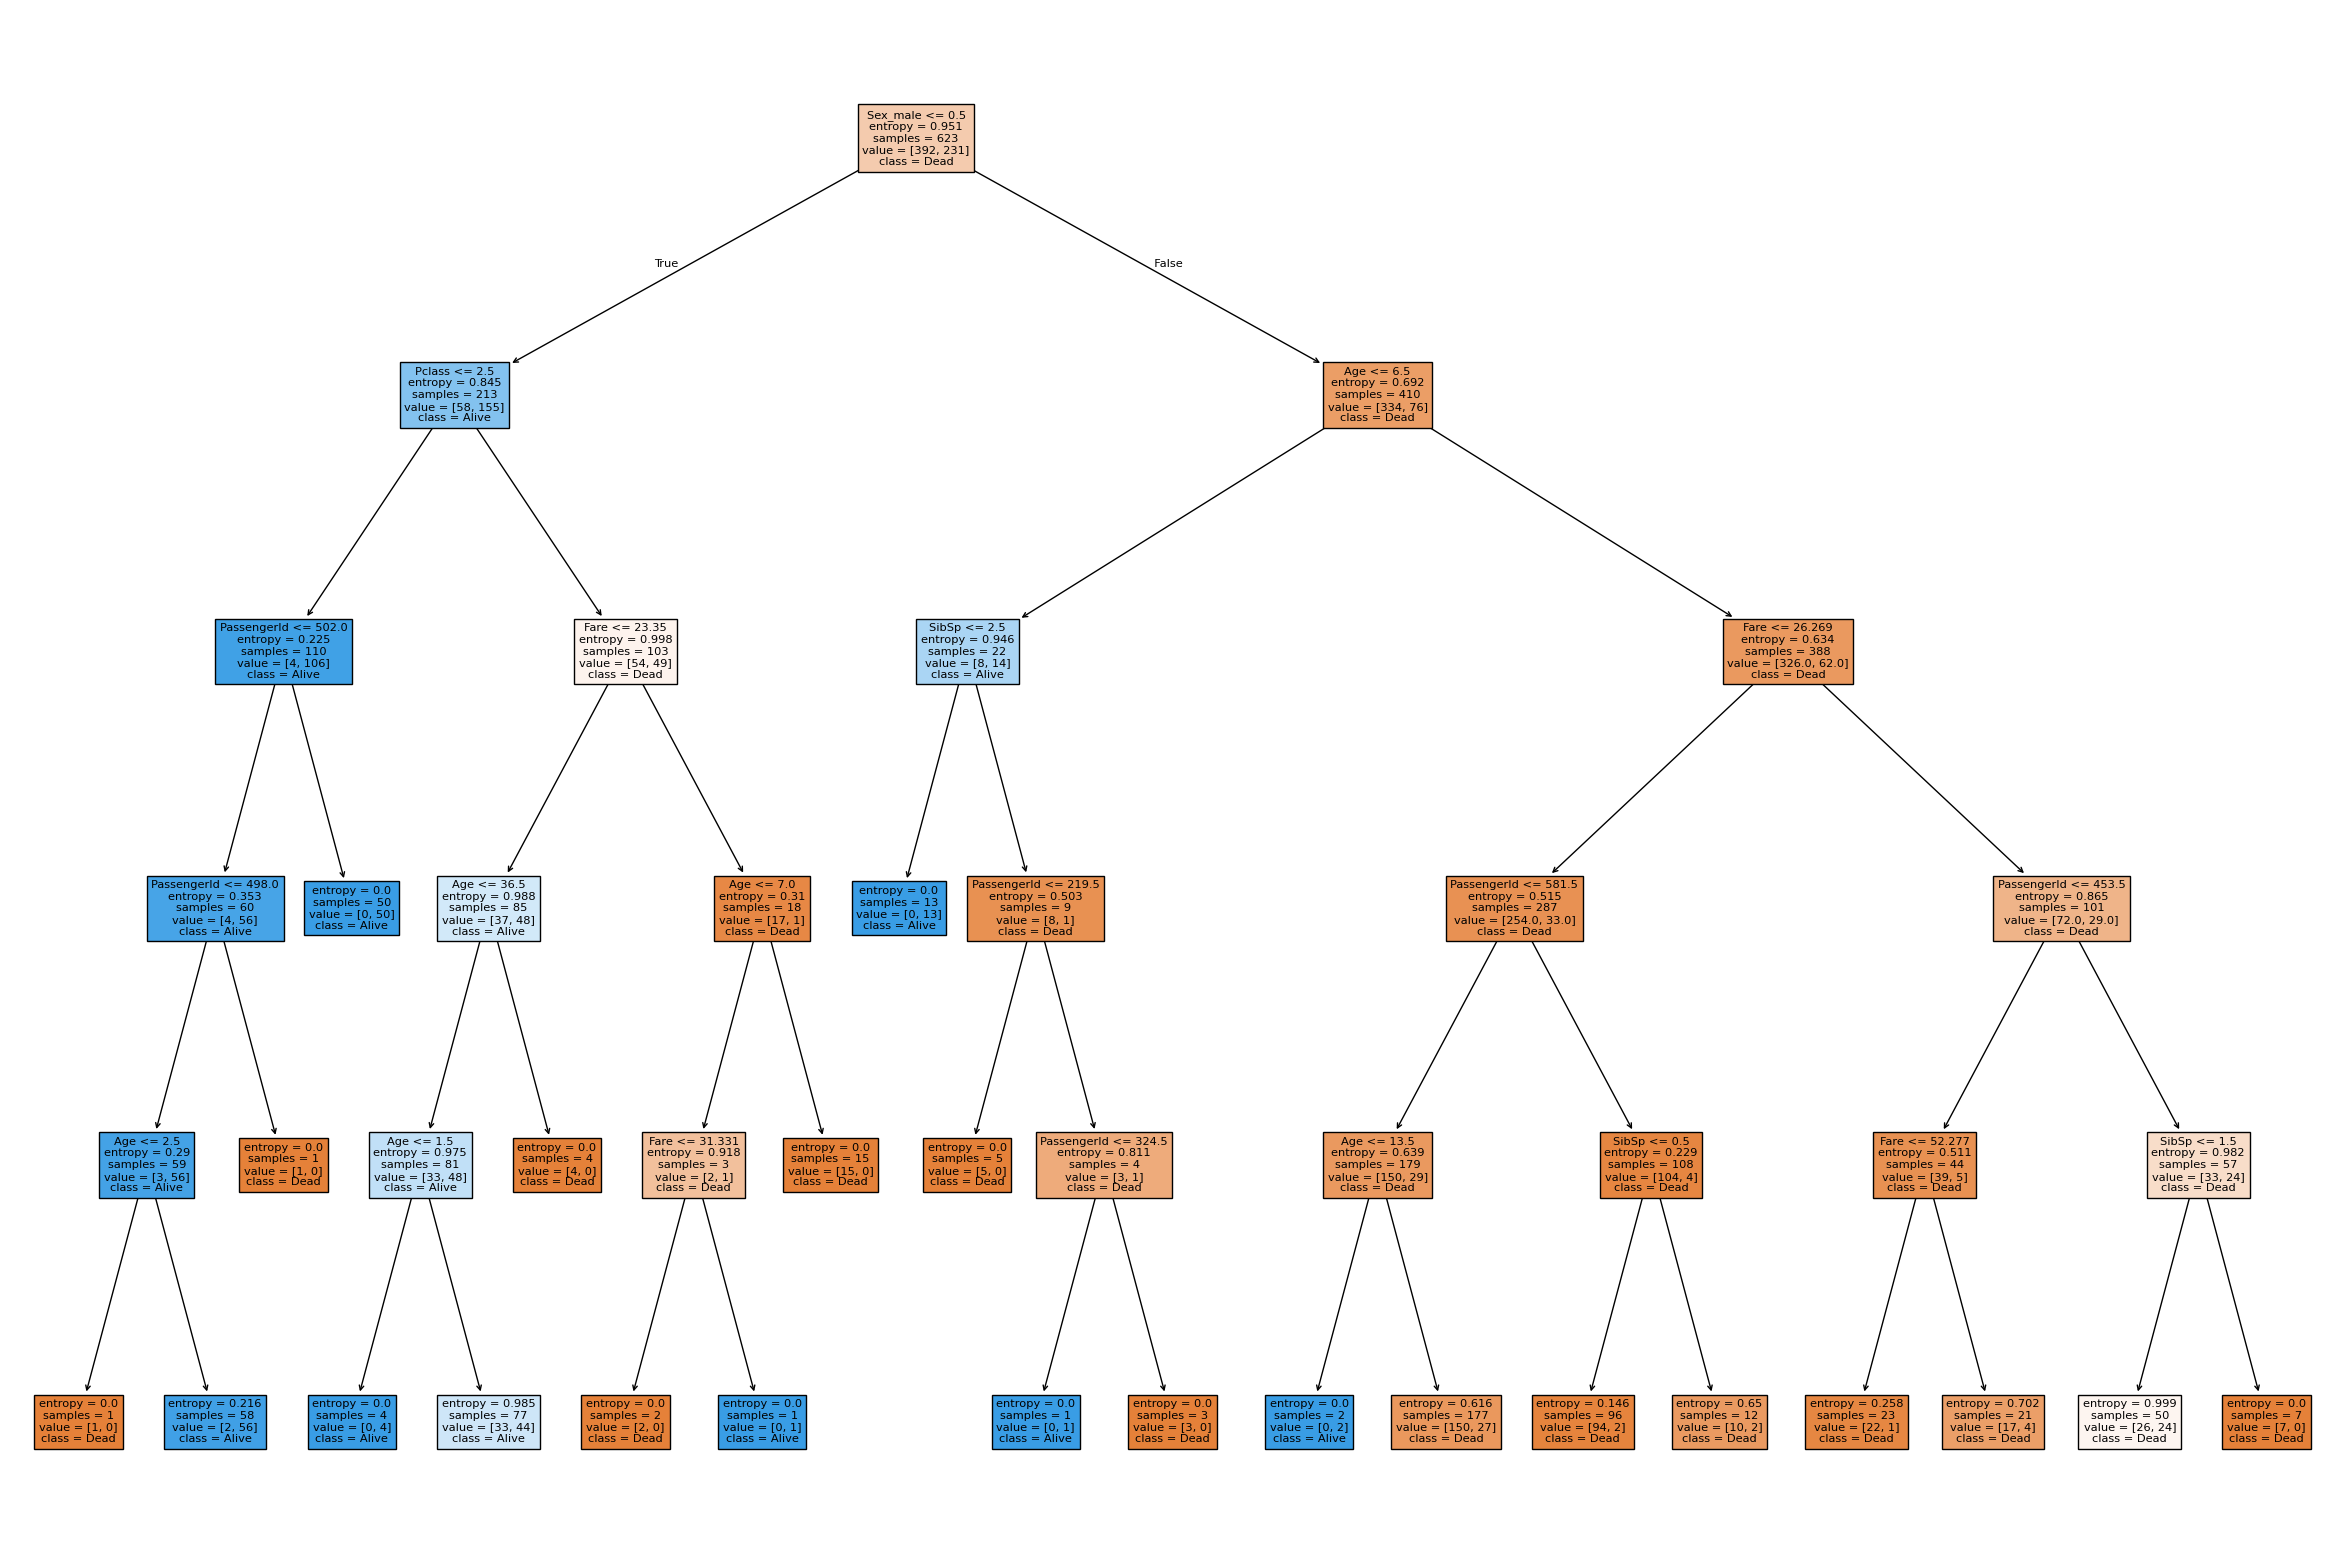

In [165]:
fig = plt.figure(figsize=(30,20))
sk.tree.plot_tree(model_dt, feature_names=p_train.columns, class_names=['Dead', 'Alive'], filled=True)

In [166]:
# make predicitons
predictions_on_test_3 = model_dt.predict(p_test)
# examine results
reports['Decision Tree'] = sk.metrics.classification_report(t_test, predictions_on_test_3, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test_3))


              precision    recall  f1-score   support

           0       0.82      0.91      0.86       157
           1       0.85      0.72      0.78       111

    accuracy                           0.83       268
   macro avg       0.84      0.82      0.82       268
weighted avg       0.83      0.83      0.83       268



Naive Bayes

In [167]:
model_nb = sk.naive_bayes.MultinomialNB()
model_nb.fit(p_train, t_train)

MultinomialNB()

In [168]:
predictions_on_test_3 = model_nb.predict(p_test)
reports['Naive Bayes'] = sk.metrics.classification_report(t_test, predictions_on_test_3, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test_3))

              precision    recall  f1-score   support

           0       0.71      0.84      0.77       157
           1       0.70      0.52      0.60       111

    accuracy                           0.71       268
   macro avg       0.71      0.68      0.68       268
weighted avg       0.71      0.71      0.70       268



KNN

In [169]:
model_knn = sk.neighbors.KNeighborsClassifier(n_neighbors=5)
model_knn.fit(p_train, t_train)

KNeighborsClassifier()

In [170]:
predictions_on_test_3 = model_knn.predict(p_test)
reports['KNN'] = sk.metrics.classification_report(t_test, predictions_on_test_3, output_dict=True)
print(sk.metrics.classification_report(t_test, predictions_on_test_3))

              precision    recall  f1-score   support

           0       0.65      0.86      0.74       157
           1       0.64      0.35      0.45       111

    accuracy                           0.65       268
   macro avg       0.65      0.61      0.60       268
weighted avg       0.65      0.65      0.62       268



## Final Report Generation

In [171]:
# Convert each report into a dataframe
dfs = []
for name, rep in reports.items():
  df = pd.DataFrame(rep).transpose()
  df['model'] = name
  dfs.append(df.reset_index().rename(columns={'index': 'class'}))

In [172]:
# Combine inta a master table
cols = ['model', 'class', 'precision', 'recall', 'f1-score', 'support']

final_df = pd.concat(dfs, ignore_index=True)
final_df = final_df[cols].sort_values(by='model').reset_index(drop=True)
final_df

,model,class,precision,recall,f1-score,support
0,Bagging Classifier,0,0.788889,0.904459,0.842730,157.000000
1,Bagging Classifier,1,0.829545,0.657658,0.733668,111.000000
2,Bagging Classifier,accuracy,0.802239,0.802239,0.802239,0.802239
3,Bagging Classifier,macro avg,0.809217,0.781058,0.788199,268.000000
4,Bagging Classifier,weighted avg,0.805728,0.802239,0.797559,268.000000
5,Bagging Classifier 2,accuracy,0.805970,0.805970,0.805970,0.805970
6,Bagging Classifier 2,weighted avg,0.811808,0.805970,0.800520,268.000000
7,Bagging Classifier 2,macro avg,0.816972,0.782923,0.790876,268.000000
8,Bagging Classifier 2,1,0.847059,0.648649,0.734694,111.000000
9,Bagging Classifier 2,0,0.786885,0.917197,0.847059,157.000000


Above is a table of all the reports I did (which was just the absolute miniumum required by the assignment.  Looking at the results in a table is useful because i can see such things as which one has the highest f1 score (in this case our Boosting Classifier) or also the fact that the plain old Decision Tree classifier is next in line (when looking at that parameter alone)<br/><br/>
While that is all fine and good. I can also see that I would never use this tool (google colab) in a real world setting becuase it's just way to cumbersome.  If i were to do this in a real world setting I would put all of this stuff into code repository and I would wrap everything in a bunch of other functions so that I wouldn't have to manually twiddle all the bits to get the most optimal set of hyperparamaters.<br/><br/>
In our particular case, the best model performance happens to be the Boosting Classifier but I would not in any way assume this is true because there simply wasn't enough tests done on various hyperparameters, and I am too lazy (and also it is not necessary per the assignment) to actually go into that much depth.
<br/><br/>
**Class Notes:**<br/><br/>
As it is the case that this is our last assignment and it will be turned in after our final class, I am going to use this opportunity to give you some feedback.  I am unlike others in this class in that I am 50 years old with 20 years of software development experience.  For me, the class was kinda annoying, yet also i learned a few things so that is good.<br/><br/>**The annoying:** a lot of repitition of concepts.  This assignment for example is all repeat of previous ideas<br/>
**The good:** Exposure to new ideas which I had not heard of before<br/>
**What to improve:** At the begining of the class you gave us two books.  Those books contain about 1100 pages of content so, for that reason, I did not read any of them.  I figured there was no point in trying to extract the useful parts of that much content.  I do plan on reading both books from cover to cover but that will probably take me a year or so to do.  My suggestion is to find parts of those books which you think are pertinent to the class and assign them as reading.



In [173]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/IS470_Assignment04.ipynb" --to html --output "/content/drive/MyDrive/Output/IS470_Assignment04.html"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470_Assignment04.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1316259 bytes to /content/drive/MyDrive/Output/IS470_Assignment04.html
